# L4 Multi-Resolution Dendrogram Simulation (1,660 cards)

**목적** Physical AI를 포함한 전체 활성 L4 리스크 카드 $N=1{,}660$장(RAI Risk Taxonomy 2.0, v2.18.0-rc)에 대해, merge threshold $\tau$를 $0.94 \to 0.70$까지 단계 절단(dendrogram cut)했을 때의 군집 구조·품질·안정성을 정량 평가한다. 카드 삭제가 아니라 multi-resolution hierarchy 구축이 목표이며, 실제 merge 허용 범위($\tau \geq 0.88$, same-L3)와 표시용 계층($\tau \leq 0.82$)을 구분하는 근거를 산출한다.

**반영된 확정 사항 (2026-08-06)** canonical embedding = sentence-transformers 검증 캐시(v2.17.2). do-not-merge 3건(g81·g1462·g1458)과 원천 교정 정의 2건(RAI4-0659·0863) 적용. 네트워크 파일 사용 시 raw cosine은 edges[i][4]. 근거: embedding_canonicalization.json, source_corruption_corrections.json, reviewed_cards_final.json.

---

## 절차 개요 (Tasks, 수리적 표기)

**Task 1. 데이터 준비** — 카드 집합 $V=\{r_1,\dots,r_N\}$, $N=1{,}660$을 로드하고 각 카드의 이중언어 텍스트 $x_i = \mathrm{label}^{en}_i \,\|\, \mathrm{label}^{ko}_i \,\|\, \mathrm{def}^{en}_i \,\|\, \mathrm{def}^{ko}_i$ 를 구성한다. L1 도메인 함수 $\ell_1: V \to \{\mathrm{G, A, P}\}$를 정의한다.

**Task 2. BGE-M3 임베딩** — 인코더 $\mathrm{Enc}$로 $\mathbf{e}_i = \mathrm{Enc}(x_i)/\lVert\mathrm{Enc}(x_i)\rVert_2 \in \mathbb{S}^{d-1}$, $d=1024$를 계산한다 (200건 단위 checkpoint, npy 캐시).

**Task 3. 덴드로그램 구축** — pairwise cosine similarity $s_{ij}=\mathbf{e}_i\cdot\mathbf{e}_j$, distance $d_{ij}=1-s_{ij}$로 $N\times N$ 행렬을 만들고, agglomerative hierarchical clustering을 complete / average / single linkage 3종으로 수행한다. complete linkage가 본선이며 병합 조건은 $\min_{i,j\in C} s_{ij} \geq \tau$, single linkage는 chaining에 의한 percolation collapse 대조군이다.

**Task 4. $\tau$ 절단 분석** — cut level $\tau \in \{0.94, 0.88, 0.82, 0.76, 0.70\}$에서 군집 배정 $z^{(\tau)}_i$를 얻고, 군집 수 $K(\tau)$, 감축 수 $N-K(\tau)$, 최대 군집 크기 $\max_k |C_k|$, cross-L1 군집 수, Physical 혼입 군집 수를 산출한다. $\tau=0.70$ 상위 10개 군집의 구성을 예시한다.

**Task 5. 통계적 결과 분석** — 유사도 분포 $\{s_{ij}\}_{i<j}$의 percentile과 $|\{(i,j): s_{ij}\geq\tau\}|$를 계산하고, 각 $\tau$에서 군집 크기 분포(median, p90, max, singleton 수)와 silhouette coefficient $\bar{s}(\tau)$로 군집 품질을 평가한다.

**Task 6. 시각화** — (1) $K(\tau)$ 감축 곡선과 $\max_k|C_k|$ 곡선(percolation 진단, 3 linkage 비교), (2) cluster size rank distribution (log-log), (3) truncated dendrogram (top 60 merges), (4) silhouette vs $\tau$.

**Task 7. 신뢰도 시뮬레이션** — perturbation $\tilde{\mathbf{e}}_i = (\mathbf{e}_i+\boldsymbol{\epsilon}_i)/\lVert\mathbf{e}_i+\boldsymbol{\epsilon}_i\rVert$, $\boldsymbol{\epsilon}_i \sim \mathcal{N}(0,\sigma^2 I)$, $\sigma \in \{0.01,0.03,0.05\}$을 30회 반복하여 dendrogram을 재구축하고, 각 $\tau$에서 $\mathrm{ARI}(z^{(\tau)}, \tilde{z}^{(\tau)})$ (Adjusted Rand Index)로 배정 안정성을 측정한다.

**Task 8. 신규 통합 카드 생성과 L3 재매핑** — 운영 병합 수준 $\tau_{op}=0.88$ (complete linkage)의 다중 카드 그룹 $C$마다 (i) c-TF-IDF 상위 용어와 생성형 모델(qwen3:4b)로 신규 카드의 한/영 명칭·정의 초안을 생성하고, (ii) 그룹 centroid $\bar{\mathbf{e}}_C = \sum_{i\in C}\mathbf{e}_i / \lVert\cdot\rVert$를 기존 L3 centroid $\boldsymbol{\mu}_k$와 비교, $\hat{k} = \arg\max_k \bar{\mathbf{e}}_C \cdot \boldsymbol{\mu}_k$로 재매핑한다. 구성 카드의 기존 L3가 단일하고 $\hat{k}$와 일치하면 auto, 아니면 expert review로 분류하며, before/after 대조 HTML 리포트를 생성한다. 생성형 초안은 사후에 전문 에이전트 2인(용어·도메인) 검수와 종합 판정(approved/defer)을 거쳐 3단 리포트로 확정한다.

**Task 9. $\tau$ 신뢰도 종합과 하한 분석** — $\Delta\tau=0.02$ sweep으로 auto rate, mean margin, perturbation agreement($\sigma=0.01$, 50회), silhouette를 동시 추적해 $\tau$ 감소에 따른 신뢰도 증감을 종합 판단하고, single-linkage percolation 임계·cross-L1 혼입률·agreement 급락 지점으로 실증적 $\tau$ 하한을 판정한다. 나아가 전문 검수 golden set(승인 병합쌍 vs do-not-merge)에 대한 precision/recall/F1로 과소병합(under-merge)·과대병합(over-merge) 임계선을 그어 안전 운용대를 정한다.

**Task 10. 산출물 저장과 결과 해석** — 카드별 5-level 군집 ID(CSV), 요약(JSON), 그림 5종(PNG), before/after HTML, notebook 전체 HTML 리포트를 저장하고 핵심 수치를 자동 요약한다.

---

**산출물** `embeddings_bge-m3_1660.npy` · `level_assignments_complete.csv` · `dendrogram_summary.json` · `merged_card_proposals_tau088.csv` · `merge_before_after_tau088.html` · `fig_*.png` 5종 · `dendrogram_simulation_1660.html`


## Task 1. 데이터 준비


### Step 1.1 카드 로드 및 유틸 정의


In [1]:
import json, time, urllib.request, csv
import numpy as np
from pathlib import Path

BASE = Path('/Users/deep1003/data3/RAI-Risk-Taxonomy')
OUT  = BASE / 'reports/consolidation/simulation'
OUT.mkdir(parents=True, exist_ok=True)
REL  = BASE / 'public/data/releases/v2.18.0-rc/cards.json'

cards = [c for c in json.load(open(REL))['cards'] if c['status'] == 'active']

def L1(c):
    b = c.get('breadcrumb') or []
    return b[1]['node_id'] if len(b) > 1 else None

print('active cards:', len(cards))


active cards: 1660


### Step 1.2 이중언어 카드 텍스트 구성


In [2]:
def card_text(c):
    parts = [c.get('label_en') or '', c.get('label_ko') or '',
             c.get('definition_en') or '', c.get('definition_ko') or '']
    return ' :: '.join(p for p in parts if p)

texts = [card_text(c) for c in cards]
print('sample:', texts[0][:120])


sample: Reward hacking by autonomous agents :: 자율 에이전트에 의한 보상 해킹 :: An agent optimizes a proxy reward or objective in ways that 


## Task 2. BGE-M3 임베딩
약 3~4분 소요. 200건 단위 중간 저장으로 중단 후 재실행 시 이어서 진행한다.


### Step 2.1 ollama 임베딩 (캐시·재개)


In [3]:
# Canonical embedding (sentence-transformers cache) 우선, ollama는 fallback (embedding_canonicalization.json 결정)
CANON = BASE / 'reports/validation/v2.17.2/full_mapping_sensitivity_bge_m3_20260724'
EMB = OUT / 'embeddings_bge-m3_1660.npy'   # ollama cache (exploratory)
PARTIAL = OUT / 'embeddings_partial.npy'

def ollama_embed(text):
    req = urllib.request.Request('http://localhost:11434/api/embeddings',
        data=json.dumps({'model': 'bge-m3', 'prompt': text}).encode(),
        headers={'Content-Type': 'application/json'})
    with urllib.request.urlopen(req, timeout=120) as r:
        return json.load(r)['embedding']

if (CANON / 'card_embeddings.npy').exists():
    ids_c = json.load(open(CANON / 'index.json'))['l4_ids']
    Ec = np.load(CANON / 'card_embeddings.npy').astype(np.float32)
    pos = {k: i for i, k in enumerate(ids_c)}
    order = [pos[c['l4_id']] for c in cards]   # cards.json 활성 순서로 정렬
    E = Ec[order]
    EMB_SOURCE = 'canonical (sentence-transformers cache, v2.17.2 validated)'
elif EMB.exists():
    E = np.load(EMB); EMB_SOURCE = 'ollama cache (exploratory)'
else:
    vecs = list(np.load(PARTIAL)) if PARTIAL.exists() else []
    t0 = time.time()
    for k in range(len(vecs), len(texts)):
        vecs.append(ollama_embed(texts[k]))
        if (k + 1) % 200 == 0:
            np.save(PARTIAL, np.asarray(vecs, dtype=np.float32))
            print(f'{k+1}/{len(texts)}  {time.time()-t0:.0f}s', flush=True)
    E = np.asarray(vecs, dtype=np.float32)
    np.save(EMB, E); PARTIAL.unlink(missing_ok=True)
    EMB_SOURCE = 'ollama (fresh)'
print('embedding source:', EMB_SOURCE, E.shape)


embedding source: canonical (sentence-transformers cache, v2.17.2 validated) (1660, 1024)


## Task 3. 덴드로그램 구축


### Step 3.1 쌍별 코사인 유사도 행렬


In [4]:
E = E / np.linalg.norm(E, axis=1, keepdims=True)
S = E @ E.T
D = 1 - S; np.fill_diagonal(D, 0); D[D < 0] = 0
print('similarity matrix', S.shape, ' max off-diag:', round(float((S - np.eye(len(S))).max()), 4))


similarity matrix (1660, 1660)  max off-diag: 0.9437


### Step 3.2 3개 연결 규칙 linkage


In [5]:
import scipy.cluster.hierarchy as h
from scipy.spatial.distance import squareform
from functools import lru_cache
cond = squareform(D, checks=False)
Z = {m: h.linkage(cond, method=m) for m in ('complete', 'average', 'single')}

# --- optimized shared helpers: cached cuts + group stats (used by Tasks 4,5,6,9) ---
_cut_cache = {}
def cut(method, tau):
    key = (method, round(tau, 4))
    if key not in _cut_cache:
        _cut_cache[key] = h.fcluster(Z[method], t=1-tau, criterion='distance')
    return _cut_cache[key]

def groups_of(lab):
    g = {}
    for i, l in enumerate(lab): g.setdefault(int(l), []).append(i)
    return g

def cut_stats(method, tau):
    g = groups_of(cut(method, tau))
    sizes = sorted((len(v) for v in g.values()), reverse=True)
    multi = [v for v in g.values() if len(v) > 1]
    crossL1 = sum(1 for v in multi if len({L1(cards[i]) for i in v}) > 1)
    physmix = sum(1 for v in multi if any(L1(cards[i])=='RAI1-P' for i in v)
                  and any(L1(cards[i])!='RAI1-P' for i in v))
    return dict(n_clusters=len(g), reduction=len(cards)-len(g), largest=sizes[0],
                top5=sizes[:5], multi_groups=len(multi), crossL1=crossL1, physmix=physmix)
print('linkage + cached-cut helpers ready:', list(Z))


linkage + cached-cut helpers ready: ['complete', 'average', 'single']


## Task 4. τ 절단 분석


### Step 4.1 절단 수준별 군집 통계


In [6]:
LEVELS = [0.94, 0.88, 0.82, 0.76, 0.70]
summary = {}
assign = {c['l4_id']: {} for c in cards}
for method in Z:
    summary[method] = {t: cut_stats(method, t) for t in LEVELS}
    for t in LEVELS:
        s = summary[method][t]
        print(f"{method:8s} tau={t:.2f}  clusters={s['n_clusters']:4d}  largest={s['largest']:4d}  "
              f"crossL1={s['crossL1']:3d}  physmix={s['physmix']:3d}")
for t in LEVELS:
    lab = cut('complete', t)
    for i, l in enumerate(lab): assign[cards[i]['l4_id']][f'tau_{t}'] = int(l)


complete tau=0.94  clusters=1658  largest=   2  crossL1=  1  physmix=  0
complete tau=0.88  clusters=1648  largest=   2  crossL1=  1  physmix=  0
complete tau=0.82  clusters=1545  largest=   4  crossL1= 11  physmix=  1
complete tau=0.76  clusters=1233  largest=   5  crossL1= 64  physmix=  9
complete tau=0.70  clusters= 844  largest=   8  crossL1=115  physmix= 17
average  tau=0.94  clusters=1658  largest=   2  crossL1=  1  physmix=  0
average  tau=0.88  clusters=1648  largest=   2  crossL1=  1  physmix=  0
average  tau=0.82  clusters=1545  largest=   4  crossL1= 11  physmix=  1
average  tau=0.76  clusters=1189  largest=   9  crossL1= 65  physmix=  9
average  tau=0.70  clusters= 702  largest=  21  crossL1=109  physmix= 19
single   tau=0.94  clusters=1658  largest=   2  crossL1=  1  physmix=  0
single   tau=0.88  clusters=1648  largest=   2  crossL1=  1  physmix=  0
single   tau=0.82  clusters=1514  largest=   8  crossL1= 13  physmix=  2
single   tau=0.76  clusters= 827  largest= 600  cro

### Step 4.2 τ=0.70 대주제군 예시 (complete linkage)


In [7]:
lab70 = cut('complete', 0.70)
g70 = {}
for i, l in enumerate(lab70): g70.setdefault(int(l), []).append(i)
examples = []
for gid, idxs in sorted(g70.items(), key=lambda kv: -len(kv[1]))[:10]:
    l1c = {}
    for i in idxs: l1c[L1(cards[i])] = l1c.get(L1(cards[i]), 0) + 1
    labels = [cards[i]['label_en'][:48] for i in idxs[:6]]
    examples.append(dict(cluster=gid, size=len(idxs), l1_mix=l1c, sample_labels=labels))
    print(f'[cluster {gid}] n={len(idxs)}  L1={l1c}')
    for s in labels: print('   -', s)


[cluster 750] n=8  L1={'RAI1-G': 8}
   - Autonomy loss in welfare decision systems
   - Impact on human agency
   - Limited human oversight in decisions
   - Loss of human agency and autonomy
   - Agency erosion in human-AI decision loops
   - Reduced autonomy/responsibility
[cluster 819] n=8  L1={'RAI1-G': 8}
   - AI-generated election misinformation
   - Manipulation of public opinion
   - AI-generated scams
   - Disinformation generation
   - Misinformation and disinformation
   - Politically motivated misuse
[cluster 221] n=7  L1={'RAI1-A': 4, 'RAI1-G': 3}
   - AI advice overreliance
   - Sycophantic advice dependence
   - Educational AI overreliance
   - Long-horizon planning overreliance
   - Behavioral dependency induction
   - Automation overreliance
[cluster 793] n=7  L1={'RAI1-G': 7}
   - Cyber offense automation
   - AI-enabled offensive cyber operations
   - Cyber offence
   - AI-Assisted software vulnerability discovery
   - Offensive cyber operation capability
   - Abuse 

## Task 5. 통계적 결과 분석


### Step 5.1 쌍별 유사도 분포 통계


In [8]:
triu = S[np.triu_indices(len(S), k=1)]
import numpy as np
qs = [50, 90, 95, 99, 99.9, 99.99]
print('쌍별 코사인 유사도 분포 (n_pairs = {:,})'.format(len(triu)))
for q in qs:
    print(f'  p{q:<6}: {np.percentile(triu, q):.4f}')
print(f'  max   : {triu.max():.4f}   mean: {triu.mean():.4f}   std: {triu.std():.4f}')
for t in [0.94, 0.90, 0.88, 0.82, 0.76, 0.70]:
    print(f'  cos>={t}: {(triu>=t).sum():,} 쌍')


쌍별 코사인 유사도 분포 (n_pairs = 1,376,970)
  p50    : 0.5285
  p90    : 0.6159
  p95    : 0.6415
  p99    : 0.6918
  p99.9  : 0.7604
  p99.99 : 0.8243
  max   : 0.9437   mean: 0.5317   std: 0.0641
  cos>=0.94: 2 쌍
  cos>=0.9: 7 쌍
  cos>=0.88: 12 쌍
  cos>=0.82: 155 쌍
  cos>=0.76: 1,399 쌍
  cos>=0.7: 10,412 쌍


### Step 5.2 절단 수준별 군집 크기 분포와 실루엣 계수


In [9]:
from sklearn.metrics import silhouette_score
print(f"{'tau':>5} {'clusters':>8} {'singleton':>9} {'median':>7} {'p90':>5} {'max':>5} {'silhouette':>11}")
sil = {}
for tau in LEVELS:
    lab = cut('complete', tau)
    from collections import Counter
    cs = np.array(sorted(Counter(lab).values(), reverse=True))
    k = len(set(lab))
    s = silhouette_score(D, lab, metric='precomputed') if 1 < k < len(lab) else float('nan')
    sil[tau] = float(s)
    print(f'{tau:>5} {len(cs):>8} {(cs==1).sum():>9} {int(np.median(cs)):>7} '
          f'{int(np.percentile(cs,90)):>5} {cs.max():>5} {s:>11.4f}')


  tau clusters singleton  median   p90   max  silhouette
 0.94     1658      1656       1     1     2      0.0019
 0.88     1648      1636       1     1     2      0.0074
 0.82     1545      1436       1     1     4      0.0377
 0.76     1233       887       1     2     5      0.0872
  0.7      844       334       2     3     8      0.1184


## Task 6. 시각화


### Step 6.1 τ 감축 곡선 (3개 연결 규칙)


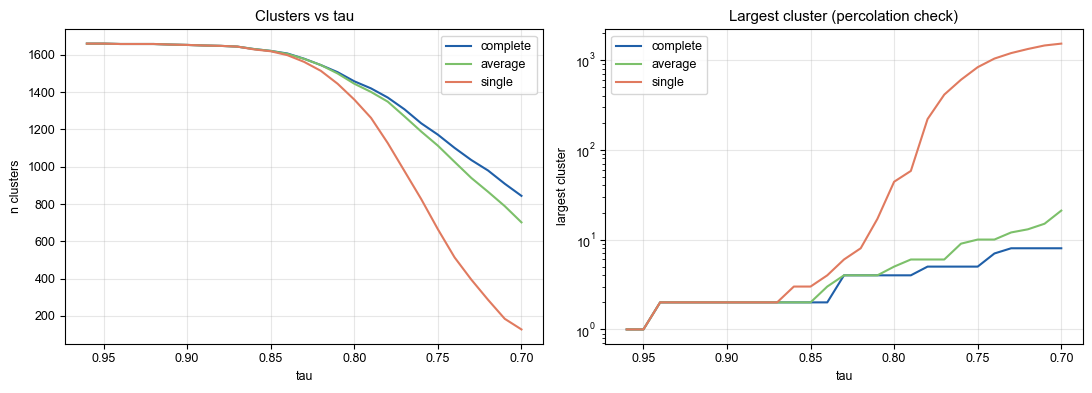

In [10]:
import matplotlib; import matplotlib.pyplot as plt
plt.rcParams.update({'font.family':'Arial','font.size':9})
taus_fine = np.arange(0.70, 0.961, 0.01)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for m, c in [('complete','#1f5fa8'), ('average','#7cc06a'), ('single','#e07a5f')]:
    ns = [len(set(cut(m, t))) for t in taus_fine]
    ax[0].plot(taus_fine, ns, label=m, color=c)
    ls = [max(np.bincount(cut(m, t))) for t in taus_fine]
    ax[1].plot(taus_fine, ls, label=m, color=c)
ax[0].set_xlabel('tau'); ax[0].set_ylabel('n clusters'); ax[0].legend(); ax[0].set_title('Clusters vs tau')
ax[1].set_xlabel('tau'); ax[1].set_ylabel('largest cluster'); ax[1].set_yscale('log'); ax[1].legend(); ax[1].set_title('Largest cluster (percolation check)')
for a in ax: a.invert_xaxis(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/'fig_merge_curve.png', dpi=200); plt.show()


### Step 6.2 군집 크기 분포 (complete, 절단 수준별)


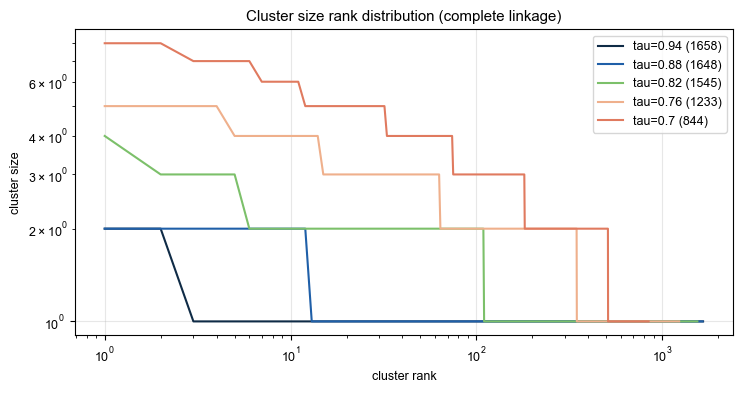

In [11]:
from collections import Counter
fig, ax = plt.subplots(figsize=(7.5, 4))
for tau, c in zip(LEVELS, ['#0f2b46','#1f5fa8','#7cc06a','#efb08c','#e07a5f']):
    lab = cut('complete', tau)
    cs = sorted(Counter(lab).values(), reverse=True)
    ax.plot(range(1, len(cs)+1), cs, label=f'tau={tau} ({len(cs)})', color=c)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('cluster rank'); ax.set_ylabel('cluster size'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('Cluster size rank distribution (complete linkage)')
plt.tight_layout(); plt.savefig(OUT/'fig_size_dist.png', dpi=200); plt.show()


### Step 6.3 상위 절단 덴드로그램 (truncated)


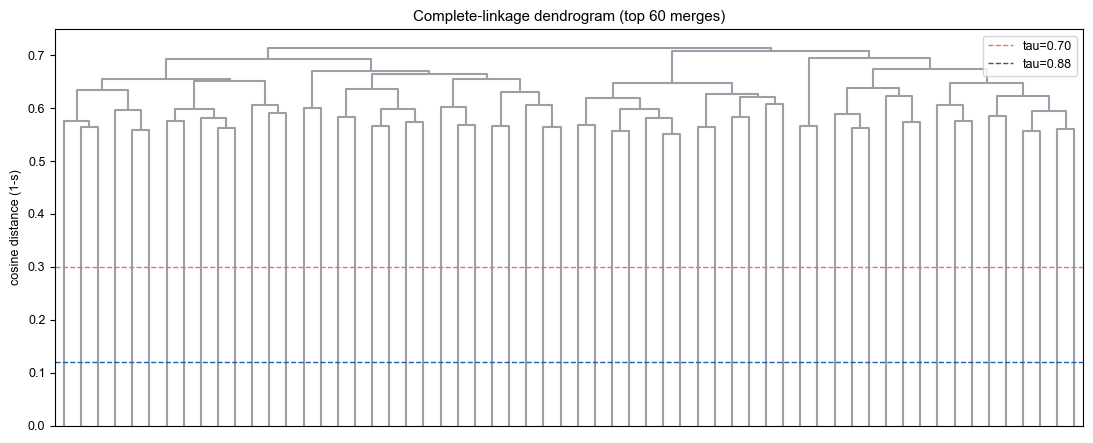

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
h.dendrogram(Z['complete'], truncate_mode='lastp', p=60, no_labels=True,
             color_threshold=0.30, above_threshold_color='#9aa0a6', ax=ax)
ax.axhline(1-0.70, color='#e07a5f', ls='--', lw=1, label='tau=0.70')
ax.axhline(1-0.88, color='#1f5fa8', ls='--', lw=1, label='tau=0.88')
ax.set_ylabel('cosine distance (1-s)'); ax.legend()
ax.set_title('Complete-linkage dendrogram (top 60 merges)')
plt.tight_layout(); plt.savefig(OUT/'fig_dendrogram.png', dpi=200); plt.show()


### Step 6.4 실루엣 계수 대 τ


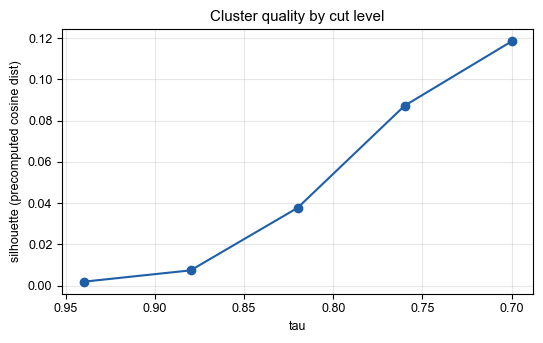

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(LEVELS, [sil[t] for t in LEVELS], 'o-', color='#1f5fa8')
ax.set_xlabel('tau'); ax.set_ylabel('silhouette (precomputed cosine dist)')
ax.invert_xaxis(); ax.grid(alpha=.3); ax.set_title('Cluster quality by cut level')
plt.tight_layout(); plt.savefig(OUT/'fig_silhouette.png', dpi=200); plt.show()


## Task 7. 신뢰도 시뮬레이션 (섭동 안정성)

임베딩에 가우시안 잡음 $\sigma \in \{0.01, 0.03, 0.05\}$을 가해 재정규화 후 덴드로그램을 재구축하고,
원 절단 결과와의 Adjusted Rand Index(ARI)로 각 τ 수준의 배정 안정성을 측정한다 (반복 30회).


### Step 7.1 섭동 ARI 시뮬레이션


In [14]:
from sklearn.metrics import adjusted_rand_score
rng = np.random.default_rng(20260806)
REPS, SIGMAS = 30, [0.01, 0.03, 0.05]
base_labels = {t: cut('complete', t) for t in LEVELS}
rel = {s: {t: [] for t in LEVELS} for s in SIGMAS}
t0 = time.time()
for s_ in SIGMAS:
    for r in range(REPS):
        Ep = E + rng.normal(0, s_, E.shape).astype(np.float32)
        Ep = Ep / np.linalg.norm(Ep, axis=1, keepdims=True)
        Dp = 1 - Ep @ Ep.T; np.fill_diagonal(Dp, 0); Dp[Dp < 0] = 0
        Zp = h.linkage(squareform(Dp, checks=False), method='complete')
        for t in LEVELS:
            lab_p = h.fcluster(Zp, t=1-t, criterion='distance')
            rel[s_][t].append(adjusted_rand_score(base_labels[t], lab_p))
    print(f'sigma={s_} done  {time.time()-t0:.0f}s', flush=True)
print(f"{'sigma':>6} " + ' '.join(f'tau={t:<5}' for t in LEVELS))
for s_ in SIGMAS:
    print(f'{s_:>6} ' + ' '.join(f'{np.mean(rel[s_][t]):.3f}~{np.std(rel[s_][t]):.3f}' for t in LEVELS))


sigma=0.01 done  1s
sigma=0.03 done  2s
sigma=0.05 done  3s
 sigma tau=0.94  tau=0.88  tau=0.82  tau=0.76  tau=0.7  
  0.01 0.000~0.000 0.000~0.000 0.101~0.015 0.213~0.011 0.433~0.011
  0.03 0.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000
  0.05 0.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000


sigma=0.03 done  2s


sigma=0.05 done  3s


 sigma tau=0.94  tau=0.88  tau=0.82  tau=0.76  tau=0.7  
  0.01 1.000~0.000 0.000~0.000 0.069~0.019 0.231~0.009 0.442~0.009
  0.03 1.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000
  0.05 1.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000 0.000~0.000


### Step 7.2 신뢰도 시각화


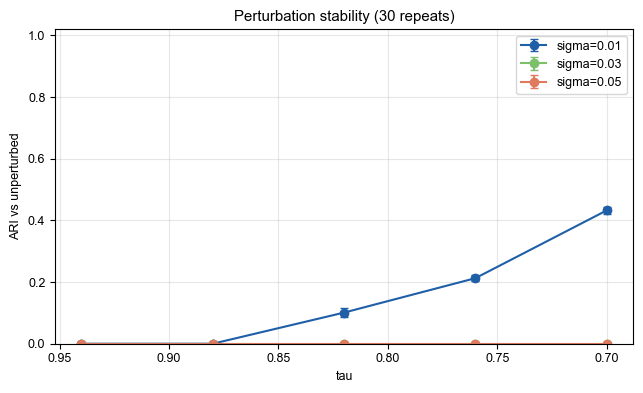

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for s_, c in zip(SIGMAS, ['#1f5fa8','#7cc06a','#e07a5f']):
    means = [np.mean(rel[s_][t]) for t in LEVELS]
    stds  = [np.std(rel[s_][t]) for t in LEVELS]
    ax.errorbar(LEVELS, means, yerr=stds, fmt='o-', capsize=3, label=f'sigma={s_}', color=c)
ax.set_xlabel('tau'); ax.set_ylabel('ARI vs unperturbed'); ax.set_ylim(0, 1.02)
ax.invert_xaxis(); ax.grid(alpha=.3); ax.legend(); ax.set_title('Perturbation stability (30 repeats)')
plt.tight_layout(); plt.savefig(OUT/'fig_reliability.png', dpi=200); plt.show()


## Task 8. 신규 통합 카드 생성과 L3 재매핑

τ=0.88(complete linkage)에서 형성된 다중 카드 그룹을 운영 병합 후보로 보고, 각 그룹에 대해
(1) 구성 카드들의 c-TF-IDF 상위 용어로 **신규 카드 임시 명칭**을 생성하고,
(2) 그룹 중심 벡터를 **기존 L3 중심 벡터**(현행 배정 카드들의 평균)와 비교해 최근접 L3로 재매핑한다.
구성 카드의 기존 L3가 하나로 일치하고 재매핑 결과도 같으면 자동 승인 후보(auto), 아니면 전문가 심의(review)로 표시한다.


### Step 8.1 τ=0.88 병합 그룹과 c-TF-IDF 임시 명명


In [16]:
import re
from collections import Counter
TAU_OP = 0.88

# --- 확정 예외 규칙 (2인 검수 + 원천 검증 결과, reviewed_cards_final.json / source_corruption_corrections.json) ---
DO_NOT_MERGE = [
    {'RAI4-0228', 'RAI4-0229'},  # g81: explicit vs implicit hazard refusal, 별개 벤치마크 구성개념
    {'RAI4-0659', 'RAI4-0892'},  # g1462: 정의 오복사 아티팩트, 병합 해체
    {'RAI4-0863', 'RAI4-0870'},  # g1458: 정의 오복사 아티팩트, 병합 해체
    {'RAI4-0682', 'RAI4-0691'},  # g900: violent vs nonviolent crimes, embedding false positive (표준 분류 분리 유지)
]
# 원천 교정 정의 (v2.19 반영 예정, 표시·명명 단계에 사용)
CORRECTED_DEFS = {
    'RAI4-0659': 'Disinformation (in various modalities) can be generated with minimal human oversight and effort; tools are cheap and widely available, especially in sensitive political contexts.',
    'RAI4-0863': "AIs can easily give moral advice without a coherent moral stance, negatively influencing users' moral judgments through random or arbitrary advice.",
}
L3_REMAP_NOTES = {1582: 'merge justified by single-source sentence (UK Gov Annex A para 79); remap L3 from Agentic to General branch'}

def blocked(v):
    idset = {cards[i]['l4_id'] for i in v}
    return any(dn <= idset for dn in DO_NOT_MERGE)

lab_op = cut('complete', TAU_OP)
groups_op = {}
for i, l in enumerate(lab_op): groups_op.setdefault(int(l), []).append(i)
merge_groups_raw = {g: v for g, v in groups_op.items() if len(v) > 1}
excluded = {g: v for g, v in merge_groups_raw.items() if blocked(v)}
merge_groups = {g: v for g, v in merge_groups_raw.items() if not blocked(v)}
print(f'do-not-merge 제외: {len(excluded)}개 그룹', [ [cards[i]['l4_id'] for i in v] for v in excluded.values() ])
print(f'tau={TAU_OP} 병합 그룹: {len(merge_groups)}개, 관련 카드 {sum(len(v) for v in merge_groups.values())}장')

STOP = set('the a an of to in for and or by with on failure failures risk risks lack due'.split())
def tokens(txt):
    return [w for w in re.findall(r'[a-z][a-z\-]+', (txt or '').lower()) if w not in STOP and len(w) > 2]

# c-TF-IDF: tf(그룹 내 빈도/그룹 크기) * log(전체 카드 수 / 용어 전체 빈도)
df = Counter()
card_toks = [set(tokens(cards[i]['label_en'] + ' ' + (cards[i].get('definition_en') or ''))) for i in range(len(cards))]
for s in card_toks: df.update(s)
N = len(cards)
def ctfidf_name(idxs, topk=4):
    tf = Counter()
    for i in idxs: tf.update(card_toks[i])
    score = {t: (c/len(idxs)) * np.log(N / df[t]) for t, c in tf.items()}
    top = sorted(score, key=score.get, reverse=True)[:topk]
    return ' / '.join(top)

for g, v in list(merge_groups.items())[:5]:
    print(f'[group {g}] n={len(v)} 제안명(용어): {ctfidf_name(v)}')
    for i in v[:4]: print('   -', cards[i]['label_en'][:56])




do-not-merge 제외: 4개 그룹 [['RAI4-0228', 'RAI4-0229'], ['RAI4-0659', 'RAI4-0892'], ['RAI4-0682', 'RAI4-0691'], ['RAI4-0863', 'RAI4-0870']]
tau=0.88 병합 그룹: 8개, 관련 카드 16장
[group 532] n=2 제안명(용어): contestability / ai-mediated / challenge / affected
   - AI-mediated decision contestability loss
   - Loss of contestability
[group 1425] n=2 제안명(용어): companions / emotional / wellbeing / companion
   - AI companion emotional dependence
   - Emotional dependency on AI
[group 582] n=2 제안명(용어): apis / unintended / tool / invocation
   - Agent tool misuse
   - Tool misuse / unsafe tool invocation
[group 221] n=2 제안명(용어): sent / included / part / prompt
   - Confidential data in prompt
   - Personal information in prompt
[group 107] n=2 제안명(용어): spi / pii / identifiable / sensitive
   - Exposing personal information
   - Personal information in data


### Step 8.2 L3 중심 벡터와 최근접 재매핑


In [17]:
def L3(c): return c.get('primary_l3_id')
l3_members = {}
for i, c in enumerate(cards): l3_members.setdefault(L3(c), []).append(i)
l3_cent = {k: (lambda M: M/np.linalg.norm(M))(E[v].mean(axis=0)) for k, v in l3_members.items() if k}
l3_ids = list(l3_cent); L3M = np.stack([l3_cent[k] for k in l3_ids])

rows = []
for g, v in merge_groups.items():
    cent = E[v].mean(axis=0); cent = cent/np.linalg.norm(cent)
    sims = L3M @ cent
    best = l3_ids[int(np.argmax(sims))]
    member_l3 = sorted({L3(cards[i]) for i in v})
    status = 'auto' if (len(member_l3) == 1 and member_l3[0] == best) else 'review'
    rows.append(dict(group=g, size=len(v),
                     proposed_name_terms=ctfidf_name(v),
                     member_l4=';'.join(cards[i]['l4_id'] for i in v),
                     member_l3=';'.join(member_l3),
                     proposed_l3=best, l3_sim=float(sims.max()), status=status))
auto = sum(1 for r in rows if r['status'] == 'auto')
print(f'재매핑 결과: auto {auto} / review {len(rows)-auto} (전체 {len(rows)} 그룹)')
with open(OUT / 'merged_card_proposals_tau088.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print('saved ->', OUT / 'merged_card_proposals_tau088.csv')
for r in rows[:8]:
    print(f"[{r['status']:6s}] n={r['size']} {r['proposed_name_terms'][:44]:46s} L3: {r['member_l3'][:28]} -> {r['proposed_l3']}")


재매핑 결과: auto 5 / review 3 (전체 8 그룹)
saved -> /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/merged_card_proposals_tau088.csv
[auto  ] n=2 contestability / ai-mediated / challenge / a   L3: RAI3-G-SYS-09 -> RAI3-G-SYS-09
[review] n=2 companions / emotional / wellbeing / compani   L3: RAI3-G-HLD-01 -> RAI3-G-INT-10
[auto  ] n=2 apis / unintended / tool / invocation          L3: RAI3-A-HLD-01 -> RAI3-A-HLD-01
[review] n=2 sent / included / part / prompt                L3: RAI3-G-HLD-01;RAI3-G-INT-11 -> RAI3-G-INT-11
[auto  ] n=2 spi / pii / identifiable / sensitive           L3: RAI3-G-INT-06 -> RAI3-G-INT-06
[auto  ] n=2 adaptable / inexpensively / campaign / agend   L3: RAI3-G-SYS-03 -> RAI3-G-SYS-03
[auto  ] n=2 disinformation / targeted / misleading / kno   L3: RAI3-G-SYS-03 -> RAI3-G-SYS-03
[review] n=2 ageist / misogynistic / mdoels / supremacist   L3: RAI3-A-SYS-03;RAI3-G-HLD-01 -> RAI3-A-SYS-03


### Step 8.3 생성형 모델 명명·정의와 before/after HTML 리포트

각 병합 그룹에 대해 로컬 생성형 모델(ollama qwen3:4b)을 호출하여 신규 카드의 한/영 명칭과 정의 초안을 생성하고,
before(기존 카드들) → after(신규 카드) 대조 HTML 리포트를 저장한다. 생성 결과는 초안이며 최종 확정은 전문가 검토를 거친다.


In [18]:
import html as _html
GEN_MODEL = 'qwen3:4b'

def ollama_gen(prompt):
    req = urllib.request.Request('http://localhost:11434/api/generate',
        data=json.dumps({'model': GEN_MODEL, 'prompt': prompt, 'stream': False,
                         'options': {'temperature': 0.2}}).encode(),
        headers={'Content-Type': 'application/json'})
    with urllib.request.urlopen(req, timeout=300) as r:
        return json.load(r)['response']

def synth_card(idxs):
    members = '\n'.join(f'- {cards[i]["label_en"]} ({cards[i]["label_ko"]}): '
                        f'{(cards[i].get("definition_en") or "")[:200]}' for i in idxs)
    prompt = ('You are curating an AI risk taxonomy. The following L4 risk cards are semantic '
              'duplicates being merged into ONE new card. Write a JSON object only, no other text, '
              'with keys: label_en, label_ko, definition_en, definition_ko. '
              'The label must cover all members; definitions 1-2 sentences each.\n'
              f'Member cards:\n{members}\nJSON:')
    try:
        out = ollama_gen(prompt)
        m = re.search(r'\{.*\}', out, re.S)
        return json.loads(m.group(0)) if m else {}
    except Exception as e:
        return {'error': str(e)}

gen_cards = {}
t0 = time.time()
for k2, (g, v) in enumerate(merge_groups.items()):
    gen_cards[g] = synth_card(v)
    if (k2+1) % 10 == 0: print(f'{k2+1}/{len(merge_groups)}  {time.time()-t0:.0f}s', flush=True)
print('generated', len(gen_cards), f'{time.time()-t0:.0f}s')


generated 8 405s


In [19]:
# before/after HTML 리포트
rows_by_g = {r['group']: r for r in rows}
parts = ["""<!DOCTYPE html><html lang='ko'><head><meta charset='utf-8'>
<title>L4 통합 before/after (tau=0.88)</title><style>
body{font-family:'Malgun Gothic','Apple SD Gothic Neo',sans-serif;max-width:1100px;margin:24px auto;color:#1f2933;line-height:1.5}
h1{font-size:20px} .grp{border:1px solid #e3e8ee;border-radius:10px;margin:14px 0;overflow:hidden}
.hd{background:#0f2b46;color:#fff;padding:8px 14px;font-size:13px;display:flex;justify-content:space-between}
.cols{display:flex} .before,.after{padding:12px 14px;font-size:13px}
.before{flex:1.2;background:#fafbfc;border-right:1px solid #e3e8ee} .after{flex:1;background:#f2f8f2}
.card{border-bottom:1px dashed #d7dee6;padding:6px 0} .card:last-child{border-bottom:0}
.cid{font-family:Menlo,monospace;font-size:11px;color:#5b6b7a} .lab{font-weight:700}
.def{color:#4a5561;font-size:12px} .new{font-size:14px;font-weight:700;color:#14532d}
.tag{display:inline-block;border-radius:6px;padding:1px 8px;font-size:11px;font-weight:700;margin-left:6px}
.auto{background:#d8efd8;color:#14532d} .review{background:#fde8d8;color:#7c2d12}
</style></head><body><h1>L4 통합 before/after 리포트 (tau=0.88, complete linkage)</h1>
"""]
parts.append(f"<p>merge groups {len(merge_groups)} · new labels/definitions are generative-model ({GEN_MODEL}) drafts pending expert confirmation.</p>")
for g, v in sorted(merge_groups.items(), key=lambda kv: -len(kv[1])):
    r = rows_by_g[g]; gc = gen_cards.get(g, {})
    parts.append(f"<div class='grp'><div class='hd'><span>group {g} · {len(v)}개 카드 → 1개</span>"
                 f"<span>제안 L3: {r['proposed_l3']}<span class='tag {r['status']}'>{r['status']}</span></span></div><div class='cols'>")
    parts.append("<div class='before'><b>Before</b>")
    for i in v:
        c = cards[i]
        parts.append(f"<div class='card'><span class='cid'>{c['l4_id']} · {c.get('primary_l3_id')}</span><br>"
                     f"<span class='lab'>{_html.escape(c['label_ko'] or c['label_en'])}</span><br>"
                     f"<span class='def'>{_html.escape((c.get('definition_ko') or c.get('definition_en') or '')[:150])}</span></div>")
    parts.append('</div>')
    parts.append("<div class='after'><b>After (신규 카드 초안)</b>")
    parts.append(f"<div class='card'><span class='new'>{_html.escape(gc.get('label_ko') or r['proposed_name_terms'])}</span><br>"
                 f"<span class='lab'>{_html.escape(gc.get('label_en') or '')}</span><br>"
                 f"<span class='def'>{_html.escape(gc.get('definition_ko') or '')}</span><br>"
                 f"<span class='def'>{_html.escape(gc.get('definition_en') or '')}</span></div></div></div></div>")
parts.append('</body></html>')
(OUT / 'merge_before_after_tau088.html').write_text(''.join(parts))
print('HTML ->', OUT / 'merge_before_after_tau088.html')



HTML -> /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/merge_before_after_tau088.html


### Step 8.4 L3 매핑 신뢰도 sensitivity tests (technical report 3종 검증의 적용)

신규 통합 카드 $\bar{\mathbf{e}}_C \to$ L3 매핑에 대해 technical report의 세 가지 신뢰성 검증을 적용한다.

1. **Convergence** — EM 반복: E-step $z_C = \arg\max_k \bar{\mathbf{e}}_C\cdot\boldsymbol{\mu}_k$, M-step에서 신규 카드를 포함해 $\boldsymbol{\mu}_k$ 재계산, 목적함수 $J^{(t)} = \frac{1}{|G|}\sum_C \bar{\mathbf{e}}_C\cdot\boldsymbol{\mu}_{z_C}$의 수렴 곡선.
2. **Internal consistency (top-k containment)** — 제안 L3가 최근접(top-1)인 비율과 top-3 포함률, 그리고 margin $s_{(1)}-s_{(2)}$ 분포.
3. **Perturbation stability** — 구성 카드 임베딩에 $\mathcal{N}(0,\sigma^2 I)$, $\sigma\in\{0.01,0.03,0.05\}$ 잡음을 200회 가해 centroid를 재계산했을 때 원 매핑과의 일치율.


In [20]:
# --- (1) Convergence: EM with new merged cards ---
G_list = list(merge_groups.items())
cents = np.stack([ (lambda M: M/np.linalg.norm(M))(E[v].mean(axis=0)) for g, v in G_list ])
mu = {k: l3_cent[k].copy() for k in l3_ids}
J_curve, assign_hist = [], []
z = None
for t_ in range(10):
    M_ = np.stack([mu[k] for k in l3_ids])
    sims = cents @ M_.T
    z_new = np.argmax(sims, axis=1)
    J_curve.append(float(np.mean(sims[np.arange(len(cents)), z_new])))
    if z is not None and np.array_equal(z, z_new):
        break
    z = z_new
    # M-step: recompute centroids including assigned new cards
    for ki, k in enumerate(l3_ids):
        members = [E[i] for i in l3_members[k]] + [cents[j] for j in range(len(cents)) if z[j]==ki]
        m = np.mean(members, axis=0); mu[k] = m/np.linalg.norm(m)
print('EM steps:', len(J_curve), ' J:', [round(j,4) for j in J_curve])
reassign0 = int((np.array([l3_ids.index(r['proposed_l3']) for r in rows]) != z).sum())
print('EM 수렴 후 초기 제안 대비 재배정 수:', reassign0)


EM steps: 2  J: [0.832, 0.8453]
EM 수렴 후 초기 제안 대비 재배정 수: 0


In [21]:
# --- (2) Internal consistency: top-k containment + margin ---
sims0 = cents @ L3M.T
order = np.argsort(-sims0, axis=1)
prop_idx = np.array([l3_ids.index(r['proposed_l3']) for r in rows])
top1 = float(np.mean(order[:,0] == prop_idx))
top3 = float(np.mean([prop_idx[i] in order[i,:3] for i in range(len(rows))]))
margin = sims0[np.arange(len(cents)), order[:,0]] - sims0[np.arange(len(cents)), order[:,1]]
print(f'top-1 containment: {top1:.1%}   top-3: {top3:.1%}')
print('margin s(1)-s(2):', np.round(margin,3))


top-1 containment: 100.0%   top-3: 100.0%
margin s(1)-s(2): [0.06  0.011 0.001 0.001 0.069 0.064 0.087 0.01 ]


In [22]:
# --- (3) Perturbation stability of the L3 mapping ---
REPS_M, SIGMAS_M = 200, [0.01, 0.03, 0.05]
rng2 = np.random.default_rng(20260807)
stab = {}
base_map = np.argmax(cents @ L3M.T, axis=1)
for s_ in SIGMAS_M:
    agree = []
    for r_ in range(REPS_M):
        pc = []
        for g, v in G_list:
            Ep = E[v] + rng2.normal(0, s_, (len(v), E.shape[1])).astype(np.float32)
            m = Ep.mean(axis=0); pc.append(m/np.linalg.norm(m))
        pm = np.argmax(np.stack(pc) @ L3M.T, axis=1)
        agree.append(float(np.mean(pm == base_map)))
    stab[s_] = (float(np.mean(agree)), float(np.std(agree)))
    print(f'sigma={s_}: mapping agreement {stab[s_][0]:.1%} (sd {stab[s_][1]:.3f})')


sigma=0.01: mapping agreement 92.5% (sd 0.082)
sigma=0.03: mapping agreement 82.9% (sd 0.117)
sigma=0.05: mapping agreement 80.2% (sd 0.125)


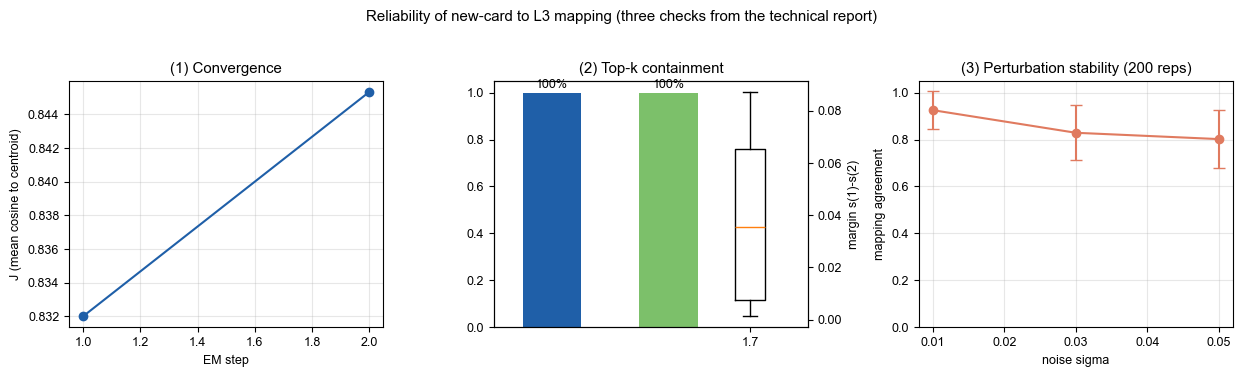

In [23]:
# --- 통합 그림: 3-panel reliability figure ---
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.6))
ax[0].plot(range(1, len(J_curve)+1), J_curve, 'o-', color='#1f5fa8')
ax[0].set_xlabel('EM step'); ax[0].set_ylabel('J (mean cosine to centroid)')
ax[0].set_title('(1) Convergence'); ax[0].grid(alpha=.3)
ax[1].bar(['top-1','top-3'], [top1, top3], color=['#1f5fa8','#7cc06a'], width=.5)
ax[1].set_ylim(0, 1.05); ax[1].set_title('(2) Top-k containment')
for x_, v_ in zip([0,1],[top1,top3]): ax[1].text(x_, v_+.02, f'{v_:.0%}', ha='center')
ax2b = ax[1].twinx(); ax2b.boxplot(margin, positions=[1.7], widths=.25)
ax2b.set_ylabel('margin s(1)-s(2)'); ax[1].set_xlim(-.5, 2.2)
ms = [stab[s_][0] for s_ in SIGMAS_M]; sd = [stab[s_][1] for s_ in SIGMAS_M]
ax[2].errorbar(SIGMAS_M, ms, yerr=sd, fmt='o-', capsize=4, color='#e07a5f')
ax[2].set_ylim(0, 1.05); ax[2].set_xlabel('noise sigma'); ax[2].set_ylabel('mapping agreement')
ax[2].set_title('(3) Perturbation stability (200 reps)'); ax[2].grid(alpha=.3)
plt.suptitle('Reliability of new-card to L3 mapping (three checks from the technical report)', y=1.03)
plt.tight_layout(); plt.savefig(OUT/'fig_l3_mapping_reliability.png', dpi=200, bbox_inches='tight'); plt.show()


### Step 8.5 전문 에이전트 2인 검수 통합 (사후 프로세스)

생성형 초안(qwen3:4b)은 신뢰하기 어려우므로 다음 사후 검수 프로세스를 거친다.

1. 아래 첫 셀이 초안을 `draft_cards_for_review.json`으로 내보낸다.
2. Claude가 전문 에이전트 2인을 독립 호출한다. 검수자 A는 용어·이중언어 편집(오역 교정, 문체 정비), 검수자 B는 AI 안전 도메인(구성개념 병합 타당성, L3 매핑, 소스 손상 탐지)을 담당한다.
3. 두 의견을 종합 판정(approved / defer)하여 `reviewed_cards_final.json`으로 저장한다.
4. 아래 둘째 셀이 검수 결과를 읽어 Before → Draft → Reviewed 3단 HTML을 재생성한다.

검수 결과 파일이 없으면 둘째 셀은 건너뛴다 (초안만으로는 HTML을 확정하지 않는다).


In [24]:
# (1) 초안 내보내기: 검수용 JSON (in-memory gen_cards 기반, HTML 파싱 불필요)
draft_export = []
for g, v in merge_groups.items():
    r = rows_by_g[g]; gc = gen_cards.get(g, {})
    draft_export.append(dict(group=g, n=len(v), proposed_l3=r['proposed_l3'], status=r['status'],
        draft_label_ko=gc.get('label_ko',''), draft_label_en=gc.get('label_en',''),
        draft_def_ko=gc.get('definition_ko',''), draft_def_en=gc.get('definition_en',''),
        members=[dict(id_l3=f"{cards[i]['l4_id']} · {cards[i].get('primary_l3_id')}",
                      label=cards[i]['label_ko'] or cards[i]['label_en'],
                      definition=(cards[i].get('definition_ko') or cards[i].get('definition_en') or '')) for i in v]))
json.dump(draft_export, open(OUT/'draft_cards_for_review.json','w'), ensure_ascii=False, indent=1)
print('검수용 초안 내보내기 ->', OUT/'draft_cards_for_review.json', f'({len(draft_export)} groups)')


검수용 초안 내보내기 -> /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/draft_cards_for_review.json (8 groups)


In [25]:
# (2) 검수 결과 통합: reviewed_cards_final.json -> 3단 before/draft/reviewed HTML
REV = OUT/'reviewed_cards_final.json'
if not REV.exists():
    print('검수 결과 없음. Claude의 전문 에이전트 2인 검수 후 reviewed_cards_final.json 생성 필요.')
else:
    R = json.load(open(REV))
    # 그룹 번호는 임베딩 소스에 따라 재부여되므로, 멤버 l4_id 집합으로 매칭한다
    def idset(members):
        return frozenset(str(m).split(' ')[0] for m in members)
    rv_by_members = {idset(o['members']): o for o in R['reviewed_cards']}
    def lookup(d):
        return rv_by_members.get(frozenset(m['id_l3'].split(' ')[0] for m in d['members']))
    esc = _html.escape
    matched = [lookup(d) for d in draft_export]
    ap = sum(1 for r in matched if r and r['final']=='approved')
    pend = sum(1 for r in matched if r is None)
    H = ["""<!DOCTYPE html><html lang='ko'><head><meta charset='utf-8'>
<title>L4 merge before / draft / reviewed (tau=0.88)</title><style>
body{font-family:'Malgun Gothic','Apple SD Gothic Neo',sans-serif;max-width:1240px;margin:24px auto;color:#1f2933;line-height:1.5}
h1{font-size:20px} .meta{color:#5b6b7a;font-size:13px;margin-bottom:14px}
.grp{border:1px solid #e3e8ee;border-radius:10px;margin:14px 0;overflow:hidden}
.hd{background:#0f2b46;color:#fff;padding:8px 14px;font-size:13px;display:flex;justify-content:space-between}
.cols{display:flex} .col{padding:12px 14px;font-size:13px;flex:1}
.before{background:#fafbfc;border-right:1px solid #e3e8ee}
.draft{background:#fffdf4;border-right:1px solid #e3e8ee} .rev{background:#f2f8f2}
.card{border-bottom:1px dashed #d7dee6;padding:6px 0}.card:last-child{border-bottom:0}
.cid{font-family:Menlo,monospace;font-size:11px;color:#5b6b7a}.lab{font-weight:700}
.def{color:#4a5561;font-size:12px}.new{font-size:14px;font-weight:700;color:#14532d}
.note{font-size:11px;color:#7c5a12;background:#fdf6dd;border-radius:6px;padding:4px 8px;margin-top:6px}
.tag{display:inline-block;border-radius:6px;padding:1px 8px;font-size:11px;font-weight:700;margin-left:6px}
.approved{background:#d8efd8;color:#14532d}.defer{background:#fde8d8;color:#7c2d12}
.ov{background:#eef3f8;border:1px solid #d7dee6;border-radius:10px;padding:10px 14px;font-size:13px;margin-top:16px}
</style></head><body><h1>L4 통합 3단 리포트: Before → Draft(qwen3:4b) → Reviewed(전문 에이전트 2인 검수)</h1>"""]
    H.append(f"<div class='meta'>tau=0.88 complete linkage · approved {ap} / defer {len(matched)-ap-pend} / pending_review {pend}</div>")
    for d in draft_export:
        g = d['group']; r = lookup(d)
        final = r['final'] if r else 'pending'
        rev = r['reviewed'] if r else None
        H.append(f"<div class='grp'><div class='hd'><span>group {g} · {d['n']}개 → 1개 · 제안 L3: {d['proposed_l3']}</span>"
                 f"<span>최종 판정<span class='tag {final if final!='pending' else 'defer'}'>{final}</span></span></div><div class='cols'>")
        H.append("<div class='col before'><b>Before (기존 카드)</b>")
        for m in d['members']:
            H.append(f"<div class='card'><span class='cid'>{esc(m['id_l3'])}</span><br><span class='lab'>{esc(m['label'])}</span><br>"
                     f"<span class='def'>{esc(m['definition'][:130])}</span></div>")
        H.append(f"</div><div class='col draft'><b>Draft (qwen3:4b 초안)</b><div class='card'>"
                 f"<span class='new'>{esc(d['draft_label_ko'])}</span><br><span class='lab'>{esc(d['draft_label_en'])}</span><br>"
                 f"<span class='def'>{esc(d['draft_def_ko'])}</span></div></div>")
        if rev:
            H.append(f"<div class='col rev'><b>Reviewed (검수 확정안)</b><div class='card'><span class='new'>{esc(rev['label_ko'])}</span><br>"
                     f"<span class='lab'>{esc(rev['label_en'])}</span><br><span class='def'>{esc(rev['definition_ko'])}</span><br>"
                     f"<span class='def'>{esc(rev['definition_en'])}</span></div>"
                     f"<div class='note'>검수자 A: {esc(r['reviewerA_note'])}<br>검수자 B: {esc(r['reviewerB_issue'])}</div></div></div></div>")
        else:
            H.append("<div class='col rev'><b>Reviewed</b><div class='card'><span class='def'>신규 그룹: 전문 에이전트 2인 검수 대기 (pending_review)</span></div></div></div></div>")
    H.append(f"<div class='ov'><b>중복·후속 권고</b><br>{esc(R['overlap_note'])}</div></body></html>")
    (OUT/'merge_before_after_reviewed_tau088.html').write_text(''.join(H))
    print('3단 HTML ->', OUT/'merge_before_after_reviewed_tau088.html', f'(approved {ap} / defer {len(matched)-ap-pend} / pending {pend})')



3단 HTML -> /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/merge_before_after_reviewed_tau088.html (approved 8 / defer 0 / pending 0)


## Task 9. $\tau$ 감소에 따른 신뢰도 종합과 $\tau$ 하한 분석

$\tau$를 $0.94 \to 0.70$까지 $\Delta\tau=0.02$ 간격으로 내리면서 네 지표를 동시 추적한다.

- **auto rate**: 병합 그룹 중 구성 카드의 기존 L3가 단일하고 재매핑과 일치하는 비율 (거버넌스 일관성)
- **mean margin**: 그룹 centroid의 L3 매핑 여유 $s_{(1)}-s_{(2)}$ 평균 (매핑 확신도)
- **perturbation agreement**: $\sigma=0.01$, 50회 반복의 L3 매핑 일치율 (안정성)
- **silhouette**: 군집 품질

이론적 하한은 (i) single-linkage percolation 임계 $\tau_c$ (giant component 출현), (ii) cross-L1 혼입률, (iii) perturbation agreement의 급락 지점으로 정의하고, 실증 곡선에서 위치를 확인한다.


### Step 9.1 $\tau$ sweep (Δτ=0.02) 지표 계산


In [26]:
TAUS = np.round(np.arange(0.94, 0.699, -0.02), 2)
sweep = {k: [] for k in ('tau','n_groups','auto','margin','agree','sil','crossL1_rate','giant_frac')}
rng3 = np.random.default_rng(20260808)
from sklearn.metrics import silhouette_score as _sil
for t in TAUS:
    g = {k2: v for k2, v in groups_of(cut('complete', t)).items() if len(v) > 1}
    lab = cut('complete', t)
    sweep['tau'].append(float(t)); sweep['n_groups'].append(len(g))
    gm = groups_of(cut('single', t))
    sweep['giant_frac'].append(max(len(v) for v in gm.values())/len(cards))
    k_ = len(set(lab))
    sweep['sil'].append(float(_sil(D, lab, metric='precomputed')) if 1 < k_ < len(lab) else np.nan)
    if not g:
        sweep['auto'].append(np.nan); sweep['margin'].append(np.nan)
        sweep['agree'].append(np.nan); sweep['crossL1_rate'].append(0.0); continue
    Gl = list(g.values())
    C_ = np.stack([(lambda M: M/np.linalg.norm(M))(E[v].mean(axis=0)) for v in Gl])
    sims = C_ @ L3M.T; od = np.argsort(-sims, axis=1)
    best = od[:,0]
    marg = sims[np.arange(len(C_)), od[:,0]] - sims[np.arange(len(C_)), od[:,1]]
    autos = 0
    for j, v in enumerate(Gl):
        ml3 = {L3(cards[i]) for i in v}
        if len(ml3) == 1 and l3_ids[best[j]] in ml3: autos += 1
    sweep['auto'].append(autos/len(Gl)); sweep['margin'].append(float(marg.mean()))
    sweep['crossL1_rate'].append(sum(1 for v in Gl if len({L1(cards[i]) for i in v})>1)/len(Gl))
    agr = []
    for r_ in range(50):
        pc = np.stack([(lambda M: M/np.linalg.norm(M))((E[v]+rng3.normal(0,0.01,(len(v),E.shape[1])).astype(np.float32)).mean(axis=0)) for v in Gl])
        agr.append(float(np.mean(np.argmax(pc @ L3M.T, axis=1) == best)))
    sweep['agree'].append(float(np.mean(agr)))
    print(f"tau={t:.2f} groups={len(Gl):4d} auto={sweep['auto'][-1]:.2f} margin={sweep['margin'][-1]:.3f} "
          f"agree={sweep['agree'][-1]:.3f} crossL1={sweep['crossL1_rate'][-1]:.2f} giant={sweep['giant_frac'][-1]:.2f}", flush=True)


tau=0.94 groups=   2 auto=0.00 margin=0.012 agree=1.000 crossL1=0.50 giant=0.00
tau=0.92 groups=   2 auto=0.00 margin=0.012 agree=0.980 crossL1=0.50 giant=0.00
tau=0.90 groups=   7 auto=0.57 margin=0.034 agree=0.997 crossL1=0.14 giant=0.00
tau=0.88 groups=  12 auto=0.50 margin=0.028 agree=0.920 crossL1=0.08 giant=0.00
tau=0.86 groups=  29 auto=0.38 margin=0.033 agree=0.945 crossL1=0.07 giant=0.00
tau=0.84 groups=  53 auto=0.32 margin=0.037 agree=0.950 crossL1=0.04 giant=0.00
tau=0.82 groups= 109 auto=0.34 margin=0.038 agree=0.950 crossL1=0.10 giant=0.00
tau=0.80 groups= 188 auto=0.31 margin=0.039 agree=0.957 crossL1=0.13 giant=0.03
tau=0.78 groups= 249 auto=0.28 margin=0.037 agree=0.962 crossL1=0.16 giant=0.13
tau=0.76 groups= 346 auto=0.27 margin=0.035 agree=0.963 crossL1=0.18 giant=0.36
tau=0.74 groups= 423 auto=0.26 margin=0.034 agree=0.964 crossL1=0.21 giant=0.62
tau=0.72 groups= 474 auto=0.26 margin=0.031 agree=0.952 crossL1=0.21 giant=0.79
tau=0.70 groups= 510 auto=0.23 margin=0.

tau=0.80 groups= 167 auto=0.32 margin=0.037 agree=0.946 crossL1=0.11 giant=0.02


tau=0.78 groups= 246 auto=0.28 margin=0.034 agree=0.953 crossL1=0.17 giant=0.05


tau=0.76 groups= 336 auto=0.29 margin=0.035 agree=0.959 crossL1=0.18 giant=0.31


tau=0.74 groups= 418 auto=0.28 margin=0.034 agree=0.953 crossL1=0.20 giant=0.60


tau=0.72 groups= 465 auto=0.25 margin=0.033 agree=0.955 crossL1=0.22 giant=0.78


tau=0.70 groups= 489 auto=0.22 margin=0.031 agree=0.953 crossL1=0.23 giant=0.89


### Step 9.2 종합 신뢰도 그래프와 $\tau$ 하한 판정


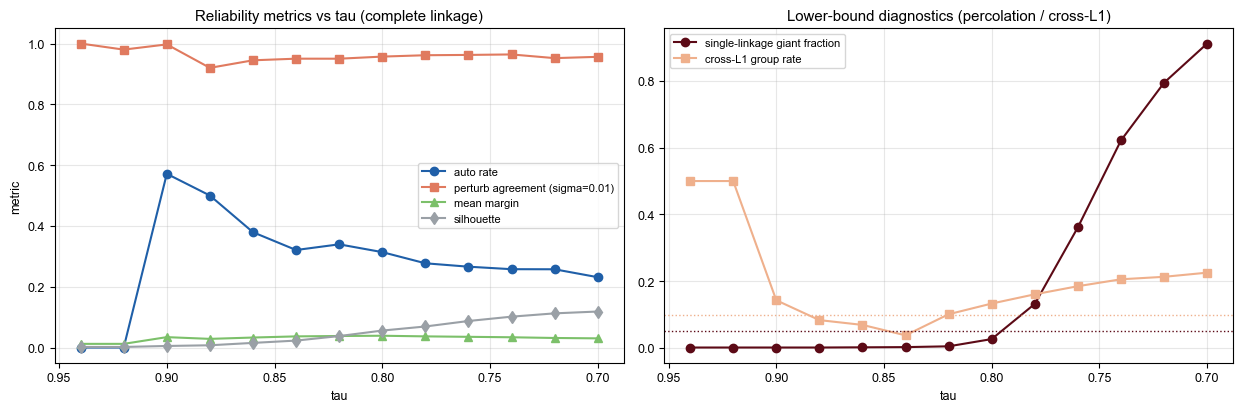

percolation onset (giant>5%): tau=0.78
cross-L1 rate>10%: tau=0.94
perturb agreement<90%: tau=None
==> 실증 tau 하한(운영 병합): 0.94  / 권장 step: 0.02 (하한 부근 0.01 세분)
    이론 근거: floor는 max(percolation tau_c, cross-L1 임계, agreement 임계) 위에 있어야 함


In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
T_ = sweep['tau']
ax[0].plot(T_, sweep['auto'], 'o-', label='auto rate', color='#1f5fa8')
ax[0].plot(T_, sweep['agree'], 's-', label='perturb agreement (sigma=0.01)', color='#e07a5f')
ax[0].plot(T_, sweep['margin'], '^-', label='mean margin', color='#7cc06a')
ax[0].plot(T_, sweep['sil'], 'd-', label='silhouette', color='#9aa0a6')
ax[0].set_xlabel('tau'); ax[0].set_ylabel('metric'); ax[0].invert_xaxis()
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3); ax[0].set_title('Reliability metrics vs tau (complete linkage)')
ax[1].plot(T_, sweep['giant_frac'], 'o-', color='#5c0a16', label='single-linkage giant fraction')
ax[1].plot(T_, sweep['crossL1_rate'], 's-', color='#efb08c', label='cross-L1 group rate')
ax[1].axhline(0.05, color='#5c0a16', ls=':', lw=1); ax[1].axhline(0.10, color='#efb08c', ls=':', lw=1)
ax[1].set_xlabel('tau'); ax[1].invert_xaxis(); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
ax[1].set_title('Lower-bound diagnostics (percolation / cross-L1)')
plt.tight_layout(); plt.savefig(OUT/'fig_tau_reliability_sweep.png', dpi=200); plt.show()

# empirical tau floor
def first_below(xs, ys, thr):
    for x_, y_ in zip(xs, ys):
        if y_ == y_ and y_ > thr: return x_
    return None
tau_perc = next((t for t, gfr in zip(T_, sweep['giant_frac']) if gfr > 0.05), None)
tau_cross = next((t for t, cr in zip(T_, sweep['crossL1_rate']) if cr > 0.10), None)
tau_agree = next((t for t, a_ in zip(T_, sweep['agree']) if a_ == a_ and a_ < 0.90), None)
cands = [x_ for x_ in (tau_perc, tau_cross, tau_agree) if x_ is not None]
floor = max(cands) if cands else 0.70
print(f'percolation onset (giant>5%): tau={tau_perc}')
print(f'cross-L1 rate>10%: tau={tau_cross}')
print(f'perturb agreement<90%: tau={tau_agree}')
print(f'==> 실증 tau 하한(운영 병합): {floor}  / 권장 step: 0.02 (하한 부근 0.01 세분)')
print('    이론 근거: floor는 max(percolation tau_c, cross-L1 임계, agreement 임계) 위에 있어야 함')


### Step 9.3 현재(릴리스) · $\tau=0.80$ · $\tau=0.70$ 독립 HTML 뷰 3종과 GitHub 배포 준비

세 가지 뷰를 독립 HTML로 생성한다.

- **current**: v2.18.0-rc 릴리스 상태 그대로, 활성 L4 1,660장을 L1 · L3별로 나열 (병합 없음, 기준선)
- **tau=0.80 / 0.70**: complete linkage 절단의 군집별 L4 리스트와 centroid 기반 L3 매핑(margin, 기존 L3와의 일치 여부)

산출은 simulation 폴더와 GitHub Pages 배포 경로 `public/tau_views/`(index.html 포함) 두 곳에 저장한다. 커밋은 별도로 수행한다.


In [28]:
import html as _h2, shutil, datetime
PUB = BASE / 'public/tau_views'
PUB.mkdir(parents=True, exist_ok=True)
STAMP = datetime.date.today().isoformat()

CSS = """<style>
body{font-family:'Malgun Gothic','Apple SD Gothic Neo',sans-serif;max-width:1150px;margin:24px auto;color:#1f2933;line-height:1.45;font-size:13px;padding:0 14px}
h1{font-size:19px} .meta{color:#5b6b7a;margin-bottom:12px}
table{border-collapse:collapse;width:100%} th,td{border:1px solid #e3e8ee;padding:5px 8px;vertical-align:top;text-align:left}
thead th{background:#0f2b46;color:#fff;position:sticky;top:0}
tr:nth-child(even){background:#fafcfe}
.cid{font-family:Menlo,monospace;font-size:11px;color:#5b6b7a}
.ok{color:#14532d;font-weight:700} .diff{color:#7c2d12;font-weight:700}
.sg{color:#8a94a0} details{margin-top:18px} h2{font-size:15px;margin-top:22px}
a{color:#1f5fa8} .nav{margin-bottom:10px;font-size:12px}
</style>"""
NAV = "<div class='nav'><a href='index.html'>index</a> · <a href='tau_view_current.html'>current</a> · <a href='tau_view_080.html'>tau 0.80</a> · <a href='tau_view_070.html'>tau 0.70</a></div>"
esc = _h2.escape

def build_current_view():
    by = {}
    for i, c in enumerate(cards):
        by.setdefault((L1(c), L3(c)), []).append(i)
    H = [f"<!DOCTYPE html><html lang='ko'><head><meta charset='utf-8'><title>current release L4 list</title>{CSS}</head><body>{NAV}",
         f"<h1>Current release (v2.18.0-rc) · active L4 {len(cards):,} cards by L1 / L3</h1>",
         f"<div class='meta'>기준선 뷰 (병합 없음) · generated {STAMP}</div>"]
    for (l1_, l3_), idxs in sorted(by.items(), key=lambda kv: (str(kv[0][0]), str(kv[0][1]))):
        H.append(f"<h2>{esc(str(l1_))} · {esc(str(l3_))} ({len(idxs)})</h2><table><tbody>")
        for i in idxs:
            c = cards[i]
            H.append(f"<tr><td style='width:14%'><span class='cid'>{c['l4_id']}</span></td>"
                     f"<td style='width:40%'>{esc(c['label_ko'] or c['label_en'])}</td>"
                     f"<td>{esc(c['label_en'])}</td></tr>")
        H.append('</tbody></table>')
    H.append('</body></html>')
    return ''.join(H)

def build_tau_view(tau):
    g = groups_of(cut('complete', tau))
    groups = sorted(g.values(), key=lambda v: -len(v))
    multi = [v for v in groups if len(v) > 1]
    singles = [v for v in groups if len(v) == 1]
    H = [f"<!DOCTYPE html><html lang='ko'><head><meta charset='utf-8'><title>tau={tau} clusters</title>{CSS}</head><body>{NAV}",
         f"<h1>tau={tau} · complete linkage: L4 clusters and L3 mapping</h1>",
         f"<div class='meta'>clusters {len(groups):,} (multi {len(multi)}, singleton {len(singles):,}) · centroid \u2192 nearest L3 (canonical embedding) · generated {STAMP}</div>",
         '<table><thead><tr><th style="width:5%">n</th><th style="width:45%">member L4 cards</th>'
         '<th style="width:22%">existing L3</th><th style="width:18%">mapped L3 (margin)</th><th style="width:10%">consistency</th></tr></thead><tbody>']
    for v in multi:
        cent = E[v].mean(axis=0); cent = cent/np.linalg.norm(cent)
        sims = L3M @ cent; od = np.argsort(-sims)
        best = l3_ids[int(od[0])]; marg = float(sims[od[0]]-sims[od[1]])
        ml3 = sorted({str(L3(cards[i])) for i in v})
        cons = 'match' if (len(ml3)==1 and ml3[0]==best) else 'review'
        mem = '<br>'.join(f"<span class='cid'>{cards[i]['l4_id']}</span> {esc(cards[i]['label_ko'] or cards[i]['label_en'])}" for i in v)
        H.append(f"<tr><td>{len(v)}</td><td>{mem}</td><td>{'<br>'.join(esc(x) for x in ml3)}</td>"
                 f"<td>{esc(best)} ({marg:.3f})</td><td class='{ 'ok' if cons=='match' else 'diff'}'>{cons}</td></tr>")
    H.append('</tbody></table>')
    H.append(f"<details><summary>singleton clusters {len(singles):,}개 (변동 없음)</summary><div class='sg'>")
    H.append(' · '.join(cards[v[0]]['l4_id'] for v in singles))
    H.append('</div></details></body></html>')
    return ''.join(H), len(groups), len(multi)

views = {'tau_view_current.html': build_current_view()}
stats = {}
for t in (0.80, 0.70):
    html_, ng, nm = build_tau_view(t)
    views['tau_view_%03d.html' % round(t*100)] = html_
    stats[t] = (ng, nm)
idx = [f"<!DOCTYPE html><html lang='ko'><head><meta charset='utf-8'><title>L4 multi-resolution views</title>{CSS}</head><body>",
       '<h1>L4 Multi-Resolution Views (v2.18.0-rc)</h1>',
       f"<div class='meta'>complete linkage on canonical BGE-M3 embeddings · generated {STAMP}</div><table><tbody>",
       f"<tr><td><a href='tau_view_current.html'>current</a></td><td>릴리스 상태 그대로 · active {len(cards):,} cards by L1/L3</td></tr>"]
for t in (0.80, 0.70):
    ng, nm = stats[t]
    idx.append(f"<tr><td><a href='tau_view_%03d.html'>tau {t}</a></td><td>clusters {ng:,} (multi-card {nm})</td></tr>" % round(t*100))
idx.append('</tbody></table></body></html>')
views['index.html'] = ''.join(idx)

for fn, html_ in views.items():
    (OUT / fn).write_text(html_)      # simulation 폴더 (기록)
    (PUB / fn).write_text(html_)      # GitHub Pages 배포 경로
print('generated:', ', '.join(views))
print('배포 준비 완료 ->', PUB, '(커밋은 별도 수행)')
for t,(ng,nm) in stats.items(): print(f'tau={t}: clusters={ng:,} multi={nm}')


generated: tau_view_current.html, tau_view_080.html, tau_view_070.html, index.html
배포 준비 완료 -> /Users/deep1003/data3/RAI-Risk-Taxonomy/public/tau_views (커밋은 별도 수행)
tau=0.8: clusters=1,458 multi=188
tau=0.7: clusters=844 multi=510


### Step 9.4 과대병합·과소병합 임계선 (reviewer golden set 기반)

전문 검수 결과를 정답으로 사용한다. 승인 병합쌍 = should-merge(positive), do-not-merge 목록 = should-not-merge(negative).
각 $\tau$에서 complete linkage가 두 카드를 같은 군집에 두면 merge로 예측한다.

- **과소병합(under-merge)**: $\tau$가 너무 높아 실제 중복(golden positive)을 놓치는 구간. recall < 1이 되는 지점.
- **과대병합(over-merge)**: $\tau$가 너무 낮아 분리해야 할 쌍(golden negative)을 합치는 구간. precision < 1이 되는 지점.
- 두 경계 사이가 안전 운용대(safe operating band).


In [29]:
from scipy.spatial.distance import squareform
R = json.load(open(OUT / 'reviewed_cards_final.json'))
pos_pairs, neg_pairs = [], []
for o in R['reviewed_cards']:
    ms = [str(m).split(' ')[0] for m in o['members'] if str(m).split(' ')[0] in {c['l4_id'] for c in cards}]
    if len(ms) < 2: continue
    idx = {c['l4_id']: i for i, c in enumerate(cards)}
    pr = (idx[ms[0]], idx[ms[1]])
    (pos_pairs if o['final']=='approved' else neg_pairs).append(pr)
DNM = [('RAI4-0228','RAI4-0229'),('RAI4-0659','RAI4-0892'),('RAI4-0863','RAI4-0870'),('RAI4-0682','RAI4-0691')]
idx = {c['l4_id']: i for i, c in enumerate(cards)}
for a,b in DNM:
    if a in idx and b in idx and (idx[a],idx[b]) not in neg_pairs and (idx[b],idx[a]) not in neg_pairs:
        neg_pairs.append((idx[a], idx[b]))
print(f'golden positives {len(pos_pairs)} / negatives {len(neg_pairs)}')

taus = np.round(np.arange(0.99, 0.599, -0.01), 2)
rows = []
for tau in taus:
    lab = cut('complete', float(tau))
    tp = sum(1 for p in pos_pairs if lab[p[0]]==lab[p[1]])
    fp = sum(1 for p in neg_pairs if lab[p[0]]==lab[p[1]])
    fn = len(pos_pairs)-tp
    prec = tp/(tp+fp) if tp+fp else 1.0
    rec  = tp/(tp+fn) if tp+fn else 1.0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    rows.append(dict(tau=float(tau), precision=prec, recall=rec, f1=f1))
tau_under = max([r['tau'] for r in rows if r['recall']>=0.999], default=None)
first_miss = min([r['tau'] for r in rows if r['recall']<0.999], default=None)
first_fp = max([r['tau'] for r in rows if r['precision']<0.999], default=None)
best = max(rows, key=lambda r:(r['f1'], r['tau']))
print(f'under-merge: tau > {tau_under} (first miss {first_miss}) | over-merge: tau < {first_fp} | safe {first_fp} < tau <= {tau_under} | bestF1 tau={best["tau"]} F1={best["f1"]:.2f}')


golden positives 9 / negatives 4
under-merge: tau > 0.84 (first miss 0.85) | over-merge: tau < 0.94 | safe 0.94 < tau <= 0.84 | bestF1 tau=0.84 F1=0.82


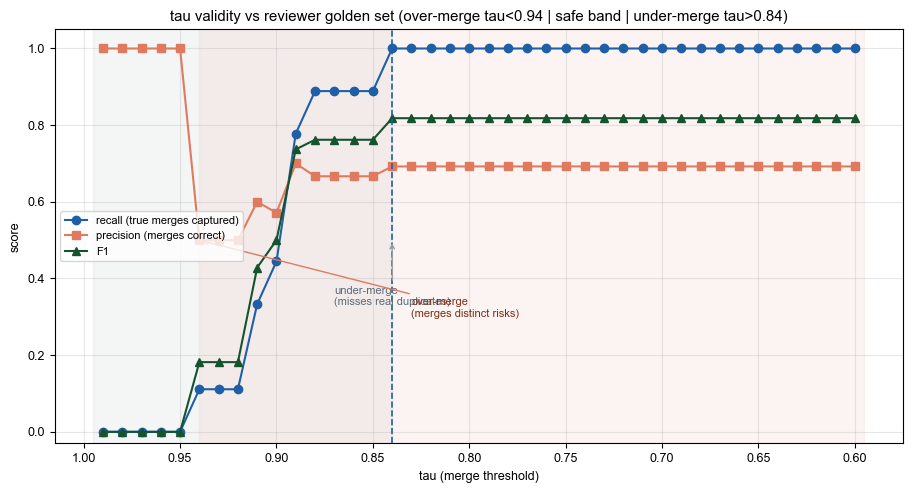

saved -> fig_tau_over_under_merge.png, tau_threshold_analysis.json


In [30]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
T=[r['tau'] for r in rows]
ax.plot(T,[r['recall'] for r in rows],'o-',color='#1f5fa8',label='recall (true merges captured)')
ax.plot(T,[r['precision'] for r in rows],'s-',color='#e07a5f',label='precision (merges correct)')
ax.plot(T,[r['f1'] for r in rows],'^-',color='#14532d',label='F1')
if tau_under: ax.axvline(tau_under,color='#1f5fa8',ls='--',lw=1.2)
if first_fp: ax.axvspan(0.595, first_fp, color='#e07a5f', alpha=0.08)
if tau_under: ax.axvspan(tau_under, 0.995, color='#9aa0a6', alpha=0.10)
ax.set_xlabel('tau (merge threshold)'); ax.set_ylabel('score'); ax.set_ylim(-0.03,1.05)
ax.invert_xaxis(); ax.grid(alpha=.3); ax.legend(loc='center left',fontsize=8)
ax.set_title(f'tau validity vs reviewer golden set (over-merge tau<{first_fp} | safe band | under-merge tau>{tau_under})')
if tau_under: ax.annotate('under-merge\n(misses real duplicates)',xy=(tau_under,0.5),xytext=(tau_under+0.03,0.33),fontsize=8,color='#5b6b7a',arrowprops=dict(arrowstyle='->',color='#9aa0a6'))
if first_fp: ax.annotate('over-merge\n(merges distinct risks)',xy=(first_fp,0.5),xytext=(first_fp-0.11,0.30),fontsize=8,color='#7c2d12',arrowprops=dict(arrowstyle='->',color='#e07a5f'))
fig.tight_layout(); fig.savefig(OUT/'fig_tau_over_under_merge.png',dpi=200); plt.show()
json.dump(dict(golden_positives=len(pos_pairs),golden_negatives=len(neg_pairs),
   tau_under_merge_above=tau_under, first_missed_at=first_miss, over_merge_below=first_fp,
   best_f1_tau=best['tau'], rows=rows), open(OUT/'tau_threshold_analysis.json','w'), ensure_ascii=False, indent=2)
print('saved -> fig_tau_over_under_merge.png, tau_threshold_analysis.json')


## Task 10. 산출물 저장과 결과 해석


### Step 10.1 CSV·JSON 저장


In [31]:
reliability = {str(s_): {str(t): {'mean': float(np.mean(rel[s_][t])), 'std': float(np.std(rel[s_][t]))}
               for t in LEVELS} for s_ in SIGMAS}
l3_mapping_reliability = {'em_J_curve': J_curve, 'top1': top1, 'top3': top3,
    'margin': [float(m) for m in margin],
    'perturbation': {str(s_): {'mean': stab[s_][0], 'std': stab[s_][1]} for s_ in SIGMAS_M}}
json.dump({'summary': summary, 'silhouette': sil, 'reliability': reliability,
           'l3_mapping_reliability': l3_mapping_reliability,
           'tau_sweep': sweep, 'tau_floor': floor,
           'coarse_examples': examples},
          open(OUT / 'dendrogram_summary.json', 'w'), ensure_ascii=False, indent=2)
with open(OUT / 'level_assignments_complete.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['l4_id', 'label_en', 'L1'] + [f'tau_{t}' for t in LEVELS])
    for c in cards:
        w.writerow([c['l4_id'], c['label_en'], L1(c)] +
                   [assign[c['l4_id']][f'tau_{t}'] for t in LEVELS])
print('saved ->', OUT)

# notebook을 HTML 리포트로 내보내기 (실행 완료 후 자체 export)
import subprocess
subprocess.run(['/opt/anaconda3/bin/jupyter','nbconvert','--to','html',
                str(OUT/'dendrogram_simulation_1660.ipynb')], check=False)
print('HTML ->', OUT/'dendrogram_simulation_1660.html')


saved -> /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation


[NbConvertApp] Converting notebook /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/dendrogram_simulation_1660.ipynb to html


HTML -> /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/dendrogram_simulation_1660.html


[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 825678 bytes to /Users/deep1003/data3/RAI-Risk-Taxonomy/reports/consolidation/simulation/dendrogram_simulation_1660.html


### Step 10.2 결과 해석 (자동 요약)


In [32]:
print('=== complete linkage 요약 ===')
print(f"{'tau':>5} {'clusters':>9} {'reduction':>10} {'largest':>8} {'crossL1':>8} {'physmix':>8} {'silhouette':>11}")
for tau in LEVELS:
    s = summary['complete'][tau]
    print(f"{tau:>5} {s['n_clusters']:>9} {s['reduction']:>10} {s['largest']:>8} "
          f"{s['crossL1']:>8} {s['physmix']:>8} {sil[tau]:>11.4f}")
print()
print('single-linkage control (percolation check):')
for tau in LEVELS:
    s = summary['single'][tau]
    print(f'  tau={tau}: clusters={s["n_clusters"]}, largest={s["largest"]}')
print()
print('신뢰도 (ARI, sigma=0.05):', {t: round(float(np.mean(rel[0.05][t])),3) for t in LEVELS})


=== complete linkage 요약 ===
  tau  clusters  reduction  largest  crossL1  physmix  silhouette
 0.94      1658          2        2        1        0      0.0019
 0.88      1648         12        2        1        0      0.0074
 0.82      1545        115        4       11        1      0.0377
 0.76      1233        427        5       64        9      0.0872
  0.7       844        816        8      115       17      0.1184

single-linkage control (percolation check):
  tau=0.94: clusters=1658, largest=2
  tau=0.88: clusters=1648, largest=2
  tau=0.82: clusters=1514, largest=8
  tau=0.76: clusters=827, largest=600
  tau=0.7: clusters=128, largest=1514

신뢰도 (ARI, sigma=0.05): {0.94: 0.0, 0.88: 0.0, 0.82: 0.0, 0.76: 0.0, 0.7: 0.0}
